# Exploratory Data Analysis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load data

In [2]:
patterns = pd.read_pickle('preprocessed_patterns.pkl')
if 'free_patterns' in patterns.columns:
    patterns['free_patterns'] = patterns['free_patterns'].fillna(False).astype(bool)

In [3]:
patterns.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 559308 entries, 1 to 801688
Data columns (total 316 columns):
 #    Column                                   Dtype              
---   ------                                   -----              
 0    pattern_id                               int64              
 1    projects_count                           int64              
 2    yarn_weight                              str                
 3    craft                                    str                
 4    is_clothing                              bool               
 5    supercategory                            str                
 6    category                                 str                
 7    subcategory                              str                
 8    babycategory                             str                
 9    created_at                               datetime64[us, UTC]
 10   favorites_count                          int64              
 11   has_uk_terminology         

In [ ]:
# Check bool columns
print(patterns.select_dtypes(include='bool').describe())

       is_clothing has_uk_terminology has_us_terminology attributes_  \
count       559308             559308             559308      559308   
unique           2                  2                  2           2   
top           True              False              False       False   
freq        347301             539443             359310      559233   

       attributes_2-at-a-time attributes_3-4-sleeve attributes_3-dimensional  \
count                  559308                559308                   559308   
unique                      2                     2                        2   
top                     False                 False                    False   
freq                   558531                554708                   516968   

       attributes_Intarsia attributes_Shetland attributes_adaptive  ...  \
count               559308              559308              559308  ...   
unique                   2                   2                   2  ...   
top          

## Pearson Correlation for projects_per_day (target)

In [4]:
# Get corr for all numeric columns against 'projects_per_day'
corr_matrix = patterns.corr(numeric_only=True).sort_values(by='projects_per_day', ascending=False)

<Axes: >

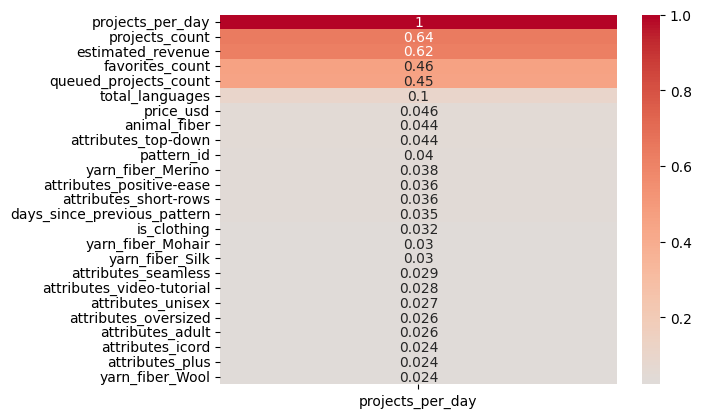

In [5]:
heatmap_data = corr_matrix['projects_per_day'].to_frame()[:25].dropna()  # Get the first 25 rows for better visualization
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)

<Axes: >

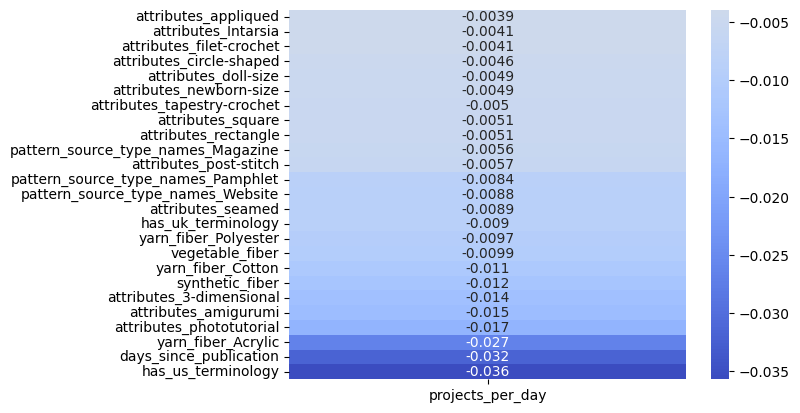

In [6]:
# Get the last 25 rows
heatmap_data = corr_matrix['projects_per_day'].to_frame().dropna()[-25:]
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)

## Box plots

<Axes: xlabel='yarn_weight', ylabel='projects_per_day'>

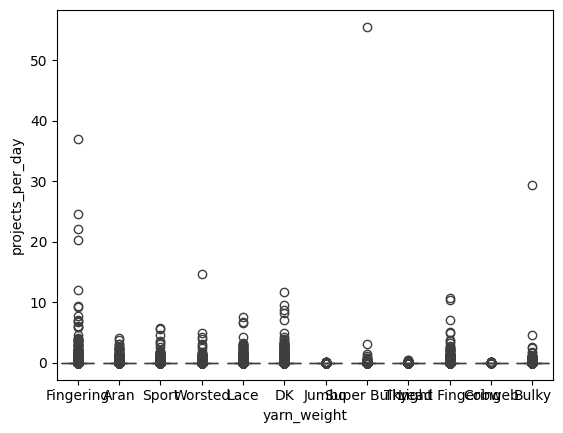

In [7]:
# Box plot comparing yarn_weight and projects_per_day
sns.boxplot(x='yarn_weight', y='projects_per_day', data=patterns)

<Axes: xlabel='craft', ylabel='projects_per_day'>

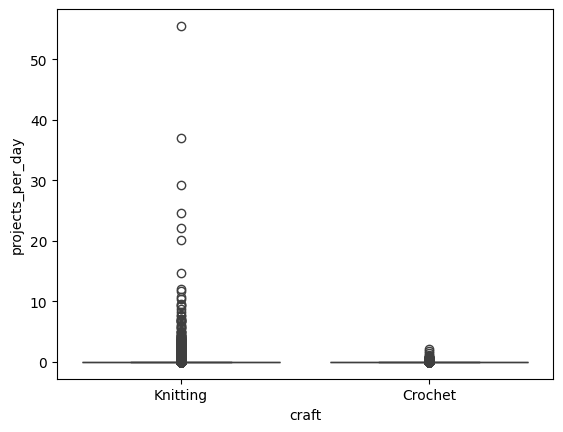

In [8]:
# Box plot comparing craft and projects_per_day
sns.boxplot(x='craft', y='projects_per_day', data=patterns)

<Axes: xlabel='season', ylabel='projects_per_day'>

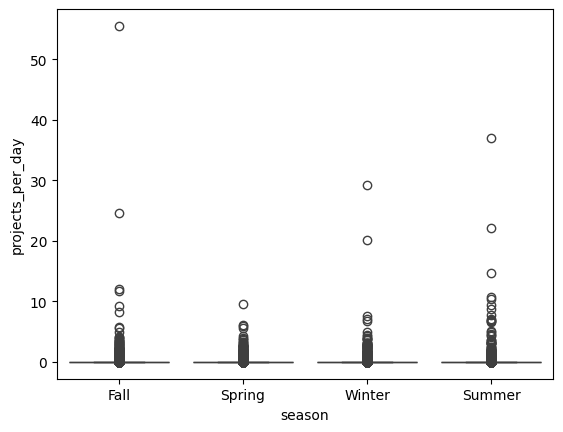

In [9]:
# Box plot comparing season and projects_per_day
sns.boxplot(x='season', y='projects_per_day', data=patterns)

## Examine relationship between total_languages and other features

<Axes: >

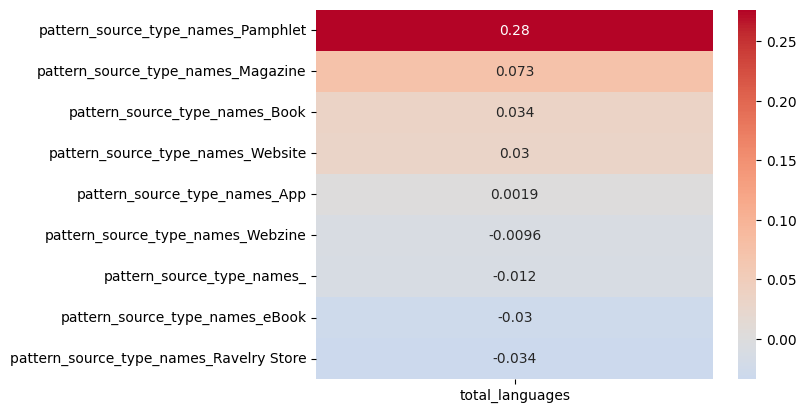

In [10]:
# total_languages vs all columns containing 'pattern_source_type_names'
pattern_source_type_names_cols = [col for col in patterns.columns if 'pattern_source_type_names' in col]
heatmap_data = corr_matrix.loc['total_languages', pattern_source_type_names_cols].to_frame().dropna().sort_values(by='total_languages', ascending=False)
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)

## Scatter plots

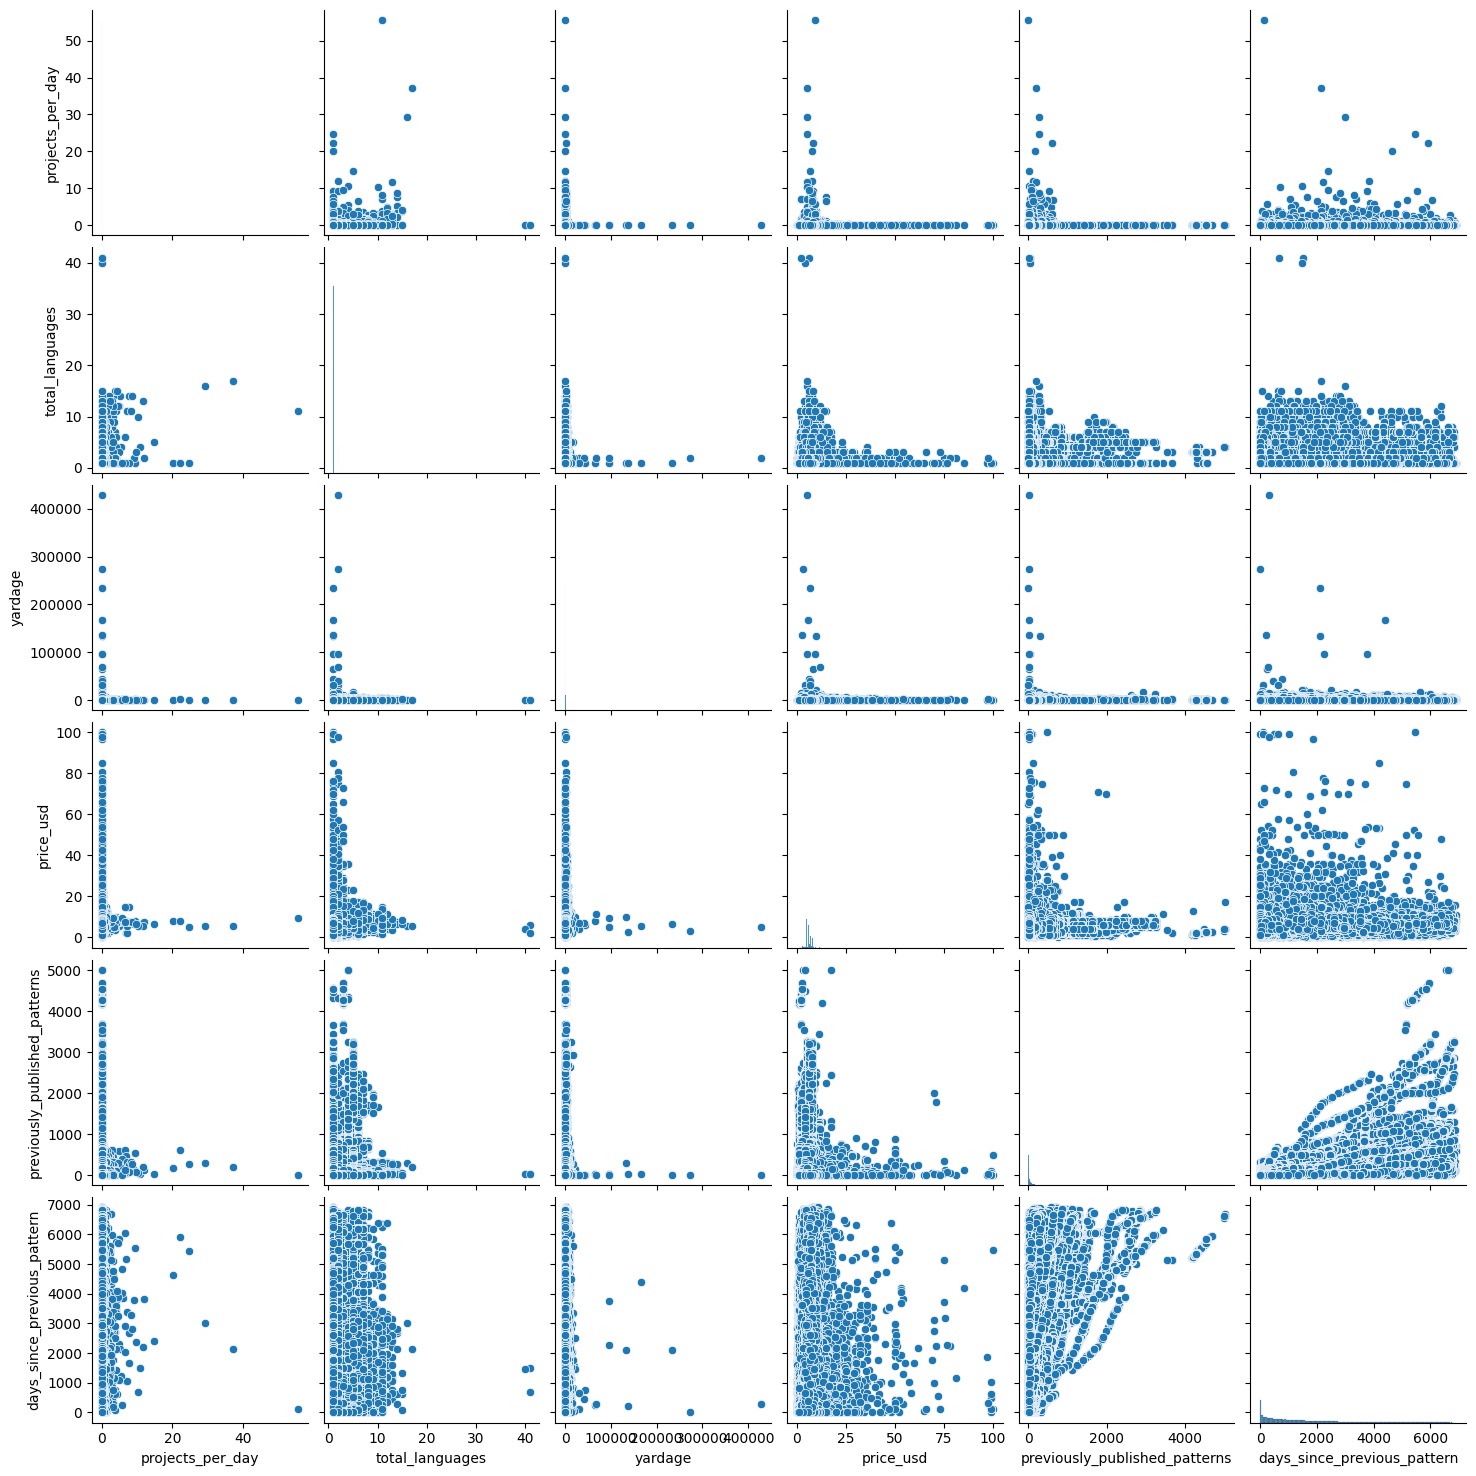

In [11]:
scatter_columns = ['projects_per_day', 'total_languages', 'yardage', 'price_usd', 'previously_published_patterns', 'days_since_previous_pattern']

sns.pairplot(patterns[scatter_columns].dropna())

In [12]:
patterns.describe()

,pattern_id,projects_count,favorites_count,author_id,queued_projects_count,yardage,previously_published_patterns,days_since_publication,projects_per_day,price_usd,days_since_previous_pattern,estimated_revenue,total_languages
count,5.593080e+05,559308.000000,559308.000000,559308.000000,559308.000000,559308.000000,559308.000000,559308.000000,559308.000000,559308.000000,559308.000000,559308.000000,559308.000000
mean,2.087193e+06,15.307526,294.001001,76564.899880,28.099493,412.522251,105.490880,2506.304778,0.008950,5.339493,1440.806184,102.653766,1.258151
std,2.599263e+06,176.454067,1286.681330,44782.402382,139.963785,1064.542127,277.811141,1619.530390,0.138536,2.325749,1437.530544,1236.679371,0.774616
min,8.500000e+01,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,33.000000,0.000000,0.001550,0.000000,0.000000,1.000000
25%,6.455878e+05,0.000000,21.000000,38614.000000,1.000000,0.000000,10.000000,1169.000000,0.000000,4.000000,306.000000,0.000000,1.000000
50%,9.980575e+05,1.000000,59.000000,81279.000000,4.000000,197.000000,31.000000,2261.000000,0.000591,5.000000,986.000000,6.000000,1.000000
75%,1.304366e+06,6.000000,183.000000,112584.000000,15.000000,550.000000,88.000000,3698.000000,0.003049,6.474820,2165.000000,35.000000,1.000000
max,7.508203e+06,49850.000000,127899.000000,164587.000000,16025.000000,428696.000000,5009.000000,6989.000000,55.542169,100.000000,6910.000000,370752.000000,41.000000


<Axes: xlabel='days_since_publication', ylabel='projects_per_day'>

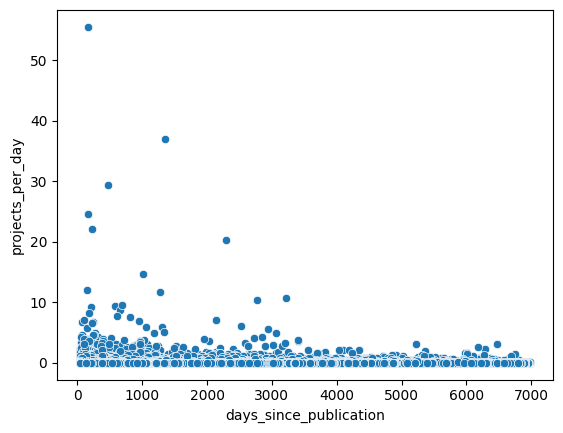

In [13]:
sns.scatterplot(x='days_since_publication', y='projects_per_day', data=patterns)

## Distribution

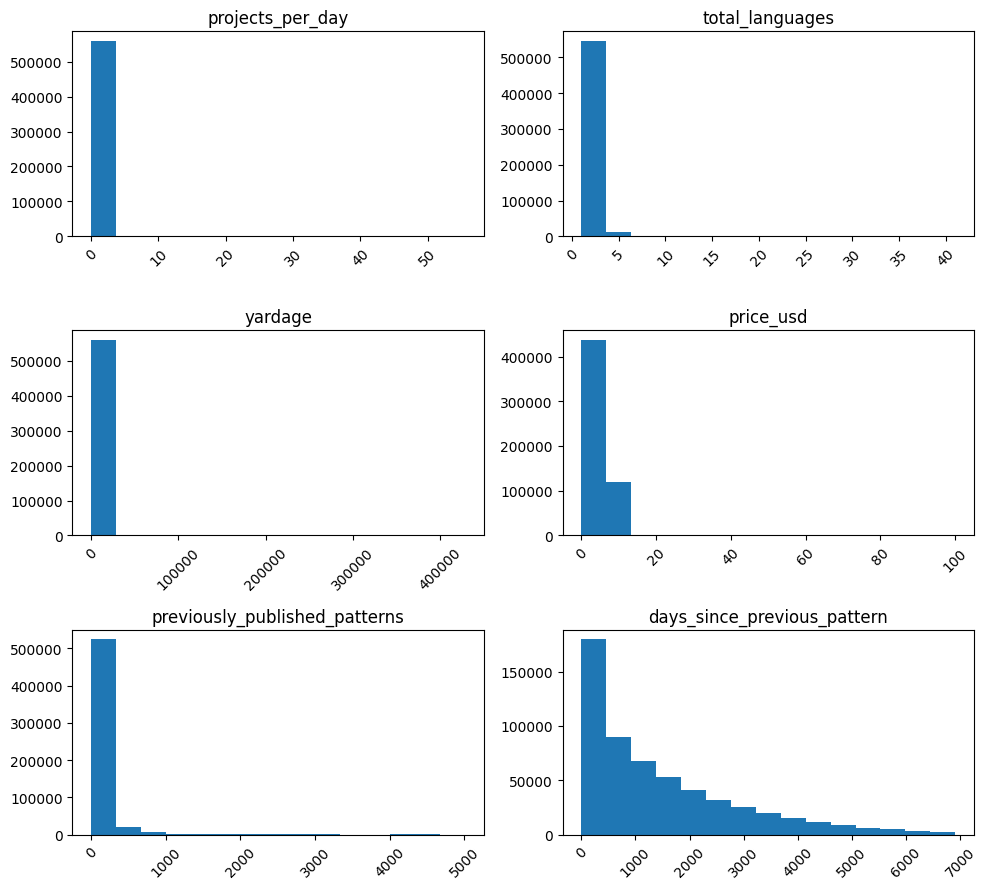

In [17]:
fig = patterns[scatter_columns].hist(bins = 15, linewidth = 1.0, xlabelsize = 10, ylabelsize = 10, xrot = 45, yrot = 0, figsize = (10, 9), grid = False)

plt.tight_layout()